## Setup

In [147]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import json
from shapely import wkb
print(os.getcwd())

from neo4j import GraphDatabase
import psycopg2
from shapely.geometry import Point
from dotenv import load_dotenv


import contextily as cx
import rasterio
from rasterio.plot import show as rioshow



/Users/spencerhoyle/Github/business-opportunity-graph/notebooks


In [148]:
load_dotenv("../.env")
CONFIG_MODE =  'LOCAL'

class Config:
    def __init__(self, mode="LOCAL"):
        mode = mode.upper()

        if mode == "LOCAL":
            self.URI = os.getenv("NEO4J_URI_LOCAL")
            self.USER = os.getenv("NEO4J_USER_LOCAL")
            self.PASSWORD = os.getenv("NEO4J_PASSWORD_LOCAL")
            self.DATABASE = os.getenv("NEO4J_DATABASE_LOCAL", "neo4j")
        elif mode == "GROUP":
            self.URI = os.getenv("NEO4J_URI_GROUP")
            self.USER = os.getenv("NEO4J_USER_GROUP")
            self.PASSWORD = os.getenv("NEO4J_PASSWORD_GROUP")
            self.DATABASE = os.getenv("NEO4J_DATABASE_GROUP", "neo4j")
        else:
            raise ValueError("Mode must be 'LOCAL' or 'GROUP'.")

config = Config(mode=CONFIG_MODE)
driver = GraphDatabase.driver(config.URI, auth=(config.USER, config.PASSWORD))

with driver.session(database=config.DATABASE) as session:
    session.run("MATCH (n) RETURN n LIMIT 1")
    print(f"Connection successful")

def query_neo4j(cypher_query: str, parameters: dict = None):
    with driver.session(database=config.DATABASE) as session:
        result = session.run(cypher_query, parameters)
        return result.data()

Connection successful


### Definitions

In [149]:
#from gemini

def get_degrees(tx, node_label: str = None, rel_type: str = None) -> dict[int, int]:
    # Construct the node pattern: (n) if node_label is None/empty, or (n:Label) otherwise
    node_pattern = f"(n{f':{node_label}' if node_label else ''})"

    # Construct the relationship pattern: -[]- if rel_type is None/empty, or -[:TYPE]- otherwise
    rel_pattern = f"-[r{f':{rel_type}' if rel_type else ''}]-"

    query = f"""
    MATCH {node_pattern}{rel_pattern}()
    RETURN elementId(n) as id, count(r) as degree
    """
    
    result = tx.run(query)
    # The result.data() method returns a list of dictionaries, 
    # e.g., [{'id': '4:0', 'degree': 5}, {'id': '4:1', 'degree': 3}]
    res = result.data()
    return res

In [150]:
#functions from Graph Data Science with Neo4J by Estelle Scifo
# def get_degrees(tx, node_label: str, rel_type: str) -> dict[int, int]:
#     query = f"""
#     MATCH (n:{node_label})-[r:{rel_type}]-() 
#     RETURN elementId(n) as id, count(r) as degree
#     """
#     result = tx.run(query)
#     res = result.data()
#     return res







In [151]:
SD_crs = 'EPSG:26946'
common_crs = "EPSG:4326"


data_path = '../data/'



In [152]:
def read_node_json(filename: str) -> pd.DataFrame:
    """Read a JSON file into a pandas DataFrame."""
    df = pd.read_json(f"../data/nodes/{filename}")
    print(f"Data read from data/nodes/{filename}")
    return df

### Load Data

In [153]:


boundaries_path ='../data/external/City_and_County_Boundaries.zip'
boundaries_gdf = gpd.read_file(boundaries_path)



communities_path = '../data/external/sd_community_boundaries.csv'
communities = gpd.read_file(communities_path)
communities_gdf = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries.from_wkt(communities['geometry'], crs=common_crs), data=communities
)
communities_gdf = communities_gdf.rename(columns={'name': 'community'})



business_location_df = pd.read_json("../data/nodes/business_location.json")
business_location_geometry = [Point(xy) for xy in zip(business_location_df.longitude, business_location_df.latitude)]
business_location_gdf = gpd.GeoDataFrame(business_location_df, crs="EPSG:4326", geometry=business_location_geometry)
business_location_gdf = business_location_gdf[business_location_gdf['longitude']!=180] #fix these outliers


block_group_df = pd.read_json("../data/nodes/block_group.json")
block_group_geometry = gpd.GeoSeries.from_wkt(block_group_df['geom_wkt'])
block_group_gdf = gpd.GeoDataFrame(block_group_df, crs="EPSG:4326", geometry=block_group_geometry)




In [154]:
zipcode_df = pd.read_json("../data/nodes/zipcode.json")
zipcode_geometry = gpd.GeoSeries.from_wkt(zipcode_df['geom_wkt'])
zipcode_gdf = gpd.GeoDataFrame(zipcode_df, crs="EPSG:4326", geometry=zipcode_geometry)

In [155]:
boundaries_gdf = boundaries_gdf.to_crs(common_crs)
communities_gdf = communities_gdf.to_crs(common_crs)



In [156]:
sd_boundaries_gdf = boundaries_gdf[boundaries_gdf['COUNTY_NAM'] == 'San Diego']
sd_boundaries_mixed = sd_boundaries_gdf[['CITY','geometry']]

sd_cities_boundaries_gdf= sd_boundaries_mixed.rename(columns={"CITY": "City"}).dissolve(by= 'City').reset_index()


In [157]:
business_location_gdf[business_location_gdf['is_franchise']==1].head()

,id,name,url,address,city,zip,latitude,longitude,categories,avg_rating,blockgroup,geom,geom_wkt,has_valid_coordinates,franchise_type,is_franchise,geometry
0,62278,AutoZone Auto Parts,https://www.google.com/maps/place//data=!4m2!3...,"AutoZone Auto Parts, 1950 Cable St, San Diego,...",San Diego,92107,32.747017,-117.248742,"[Auto parts store, Car accessories store, Car ...",4.5,75023.0,0101000020E6100000A5886764EB4F5DC0EA854C439E5F...,POINT(-117.2487422 32.7470173),True,FRANCHISE,1.0,POINT (-117.24874 32.74702)
7,62378,Sanctuary at San Elijo Hills by Richmond Ameri...,https://www.google.com/maps/place//data=!4m2!3...,Sanctuary at San Elijo Hills by Richmond Ameri...,San Marcos,92078,33.104938,-117.175916,[Home builder],4.0,200431.0,0101000020E6100000F6B52E35424B5DC0C70DBF9B6E8D...,POINT(-117.175916 33.104938),True,FRANCHISE,1.0,POINT (-117.17592 33.10494)
11,62464,Sharetea,https://www.google.com/maps/place//data=!4m2!3...,"Sharetea, 9827 Mira Mesa Blvd, San Diego, CA 9...",San Diego,92131,32.916619,-117.114178,"[Bubble tea store, Dessert shop]",4.4,170226.0,0101000020E61000000DFB3DB14E475DC034F279C55375...,POINT(-117.114178 32.916619),True,FRANCHISE,1.0,POINT (-117.11418 32.91662)
13,62486,BevMo!,https://www.google.com/maps/place//data=!4m2!3...,"BevMo!, 212 N El Camino Real, Encinitas, CA 92024",Encinitas,92024,33.048929,-117.261781,"[Wine store, Beer store, Liquor store]",4.4,176061.0,0101000020E61000004A2DEF05C1505DC0D1AB014A4386...,POINT(-117.2617812 33.0489285),True,FRANCHISE,1.0,POINT (-117.26178 33.04893)
15,62509,Fred Astaire Dance Studios,https://www.google.com/maps/place//data=!4m2!3...,"Fred Astaire Dance Studios, 845 S Coast Hwy, O...",Oceanside,92054,33.187672,-117.372873,[Dance school],5.0,182011.0,0101000020E6100000EE23B726DD575DC0AA317C9F0598...,POINT(-117.372873 33.1876716),True,FRANCHISE,1.0,POINT (-117.37287 33.18767)


In [158]:
state_df = read_node_json("state.json")
county_df = read_node_json("county.json")
city_df = read_node_json("city.json")
zipcode_df = read_node_json("zipcode.json")
community_df = read_node_json("community.json")
blockgroup_df = read_node_json("block_group.json")
brand_df = read_node_json("brand.json")
business_location_df = read_node_json("business_location.json")
zone_location_df = read_node_json("zone_location.json")
zone_type_df = read_node_json("zone_type.json")


Data read from data/nodes/state.json
Data read from data/nodes/county.json
Data read from data/nodes/city.json
Data read from data/nodes/zipcode.json
Data read from data/nodes/community.json
Data read from data/nodes/block_group.json
Data read from data/nodes/brand.json
Data read from data/nodes/business_location.json
Data read from data/nodes/zone_location.json
Data read from data/nodes/zone_type.json


In [159]:
zone_location_df.describe()

,id,imp_date,shape_length,shape_area
count,3677.000000,3.677000e+03,3677.000000,3.677000e+03
mean,1839.000000,1.283777e+12,6371.246213,2.446850e+06
std,1061.602798,2.027504e+11,16695.839735,1.883789e+07
min,1.000000,1.084320e+12,2.384195,1.096053e-02
25%,920.000000,1.141085e+12,1518.738798,9.238434e+04
50%,1839.000000,1.141085e+12,3116.274208,3.594703e+05
75%,2758.000000,1.483142e+12,6066.610533,1.142353e+06
max,3677.000000,1.733011e+12,488287.762815,7.040379e+08


<Axes: >

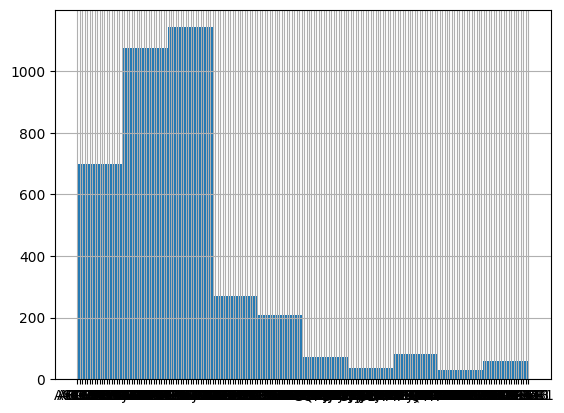

In [160]:
zone_location_df['zone_name'].hist()

## Visualizations

### Graph Degree Distribution

In [161]:
def plot_degree_distribution(degrees: pd.Series, log_mode: bool = True, label = ""):
    # define figure and subplots
    fig = plt.figure(figsize=(12, 8))
    ax1 = fig.subplots(1, 1)

    # compute and draw degree distribution
    distribution = degrees.value_counts().sort_index()
    distribution.plot(
        ax=ax1, 
        marker="o", color="k",
        title=f"Degree Distribution: {label}", xlabel="Degree", ylabel="nbOccurrences",
        logy=log_mode, 
        logx=log_mode
    )

    fig.tight_layout()
    return fig

[{'id': '4:554f452c-9aac-4200-8d69-cbab58ed1633:0', 'degree': 3}, {'id': '4:554f452c-9aac-4200-8d69-cbab58ed1633:1', 'degree': 3}, {'id': '4:554f452c-9aac-4200-8d69-cbab58ed1633:2', 'degree': 4}]


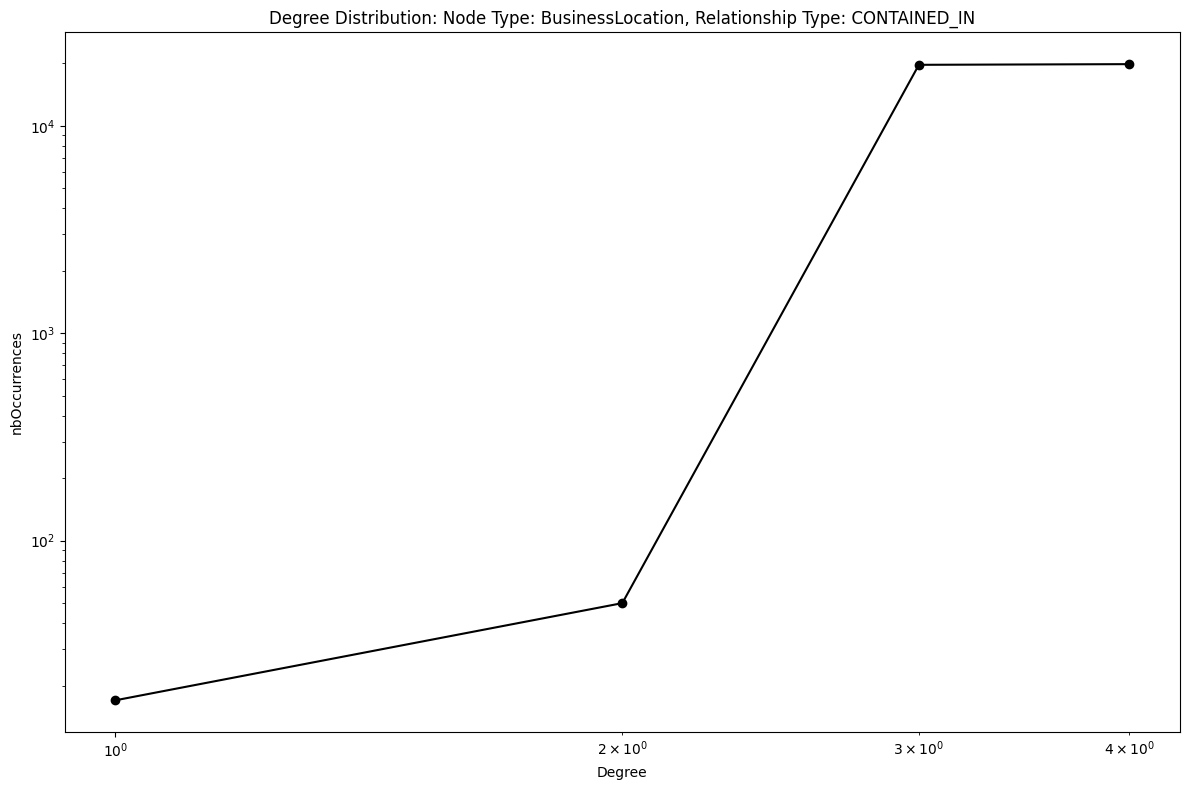

In [162]:
node_type = 'BusinessLocation'
relatiionship_type = 'CONTAINED_IN'


if node_type == 'Any':
    nt = ""
elif node_type == 'All':
    nt = ""

else:
    nt = node_type

if relatiionship_type == 'Any':
    rt = ""
elif relatiionship_type == 'All':
    rt = ""

else:
    rt = relatiionship_type

with driver.session(database=config.DATABASE) as s:
    # degree_data = s.execute_read(get_degrees, "BusinessLocation", "contained_in")
    degree_data = s.execute_read(get_degrees, nt, rt)    
print(degree_data[:3])


data = pd.DataFrame(degree_data)
plot_degree_distribution(data.degree, label= f'Node Type: {node_type}, Relationship Type: {relatiionship_type}');

In [163]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


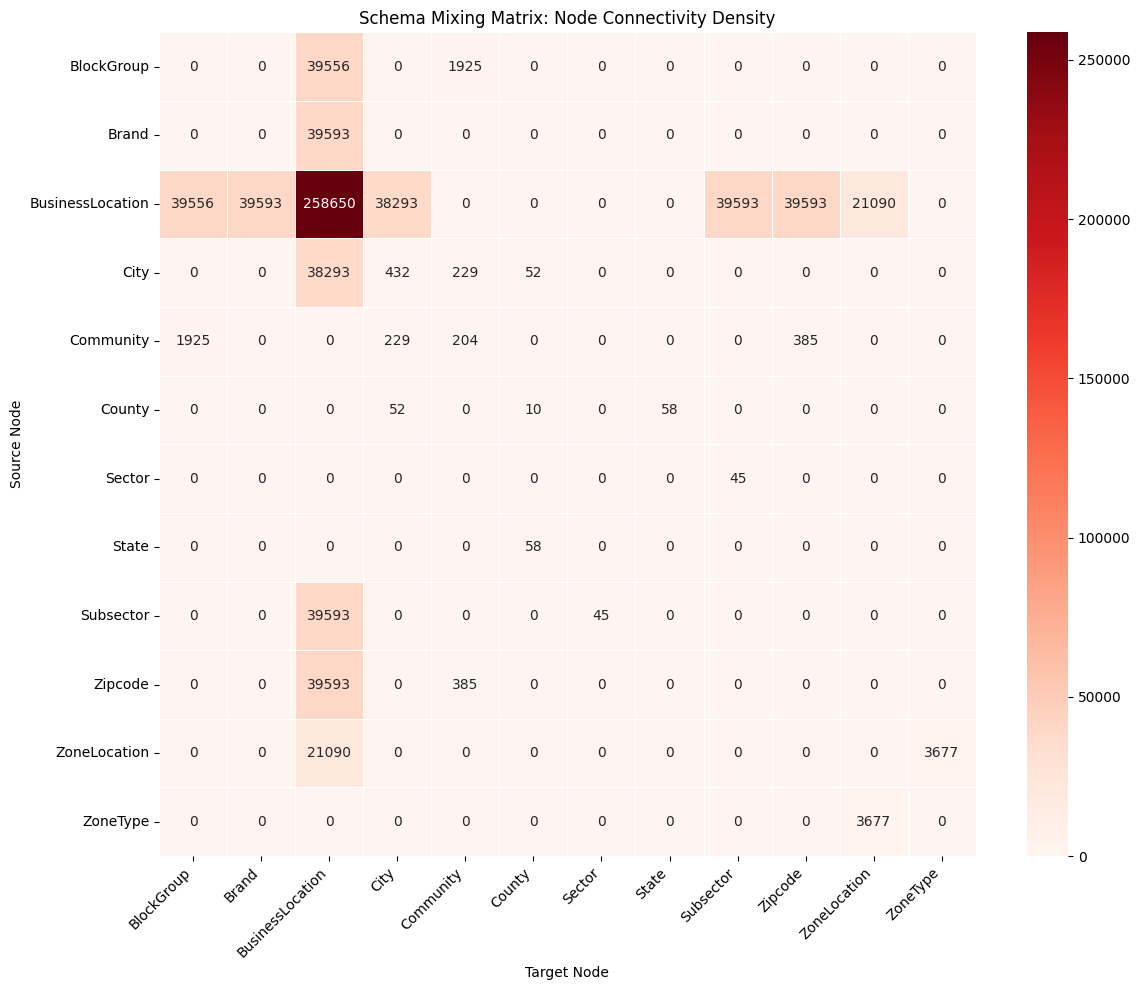

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the Cypher Query
# This counts every relationship edge grouped by the types of nodes it connects
query = """
MATCH (n)-[r]-(m)
RETURN labels(n)[0] AS Source, labels(m)[0] AS Target, count(r) AS Weight
ORDER BY Source, Target
"""

# 2. Execute Query
with driver.session(database=config.DATABASE) as session:
    result = session.run(query)
    data = [record.data() for record in result]

# 3. Process Data
df = pd.DataFrame(data)

# Create the Matrix (Pivot Table)
# Rows = Source Node, Columns = Target Node, Values = Number of Connections
mixing_matrix = df.pivot(index="Source", columns="Target", values="Weight")
mixing_matrix = mixing_matrix.fillna(0) # Zero implies no direct relationship exists

# 4. Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(mixing_matrix, annot=True, fmt='g', cmap='Reds', linewidths=.5)

plt.title('Schema Mixing Matrix: Node Connectivity Density')
plt.ylabel('Source Node')
plt.xlabel('Target Node')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/862216003.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = matrix.applymap(lambda x: str(x) if x > 0 else "")


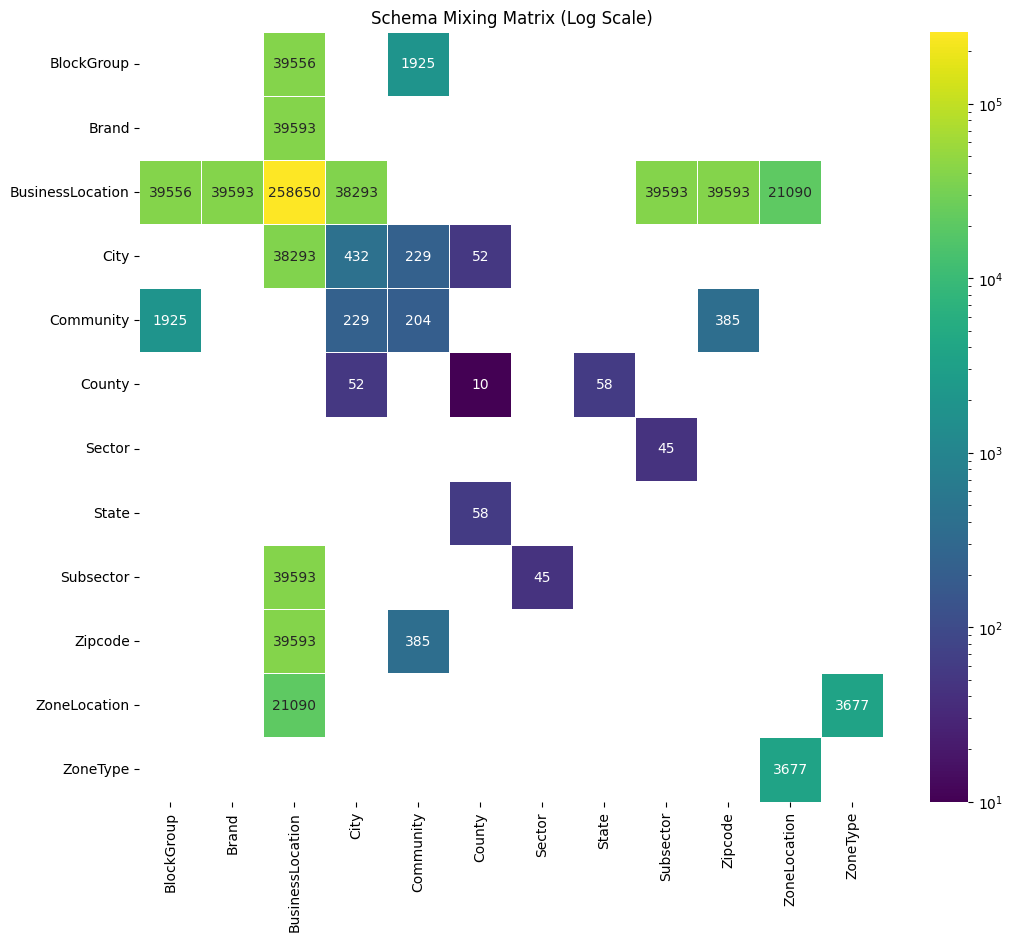

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import pandas as pd
# 1. Pivot the Data
nodes = sorted(list(set(df['Source']).union(set(df['Target']))))
matrix = pd.DataFrame(0, index=nodes, columns=nodes)
for _, row in df.iterrows():
    matrix.loc[row['Source'], row['Target']] = row['Weight']

# 2. Create Annotations (Hide Zeros)
annot_labels = matrix.applymap(lambda x: str(x) if x > 0 else "")

# 3. Plot with LogNorm
plt.figure(figsize=(12, 10))
sns.heatmap(matrix, 
            annot=annot_labels, 
            fmt='', 
            norm=LogNorm(),     # <--- The key fix
            cmap='viridis',     # <--- A high-contrast colormap
            linewidths=.5,
            mask=(matrix==0))   # <--- Hides the zeros

plt.title('Schema Mixing Matrix (Log Scale)')
plt.show()

### Maps

In [166]:
boundaries_zip = '../data/external/City_and_County_Boundaries.zip'
boundaries_path = os.path.join(data_path, boundaries_zip)
boundaries_gdf = gpd.read_file(boundaries_path)


boundaries_gdf = boundaries_gdf.to_crs(common_crs)

sd_boundaries_gdf = boundaries_gdf[boundaries_gdf['COUNTY_NAM'] == 'San Diego']
sd_county_geom = sd_boundaries_gdf.geometry.union_all()
sd_county_gdf = gpd.GeoDataFrame(
    geometry=[sd_county_geom], 
    crs=sd_boundaries_gdf.crs
)

sd_county_gdf['name'] = "San Diego County"


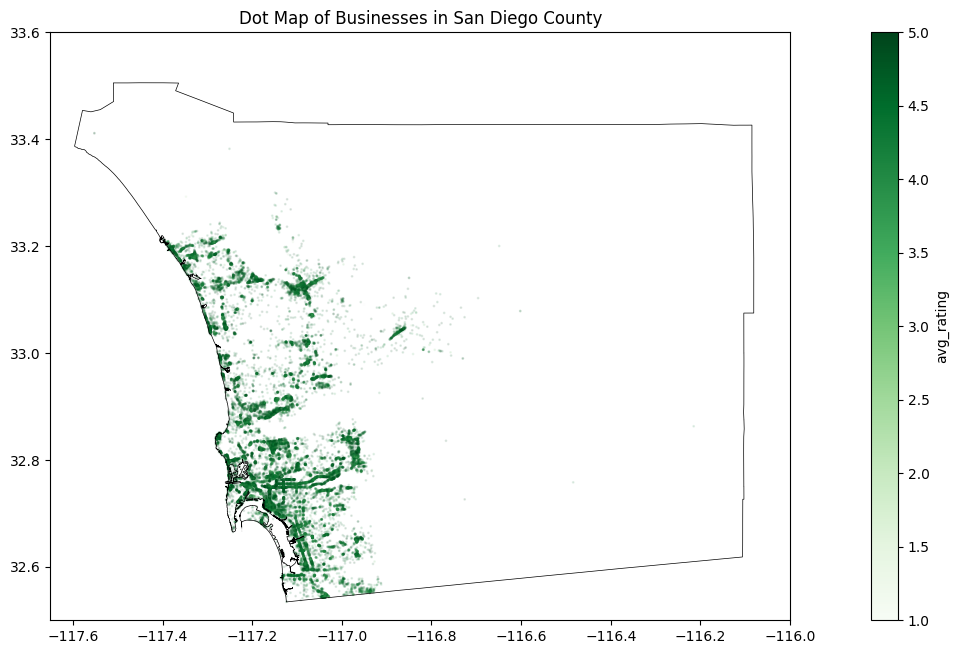

In [167]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig1, ax = plt.subplots(figsize=(10, 10))

# create a colorbar axes whose height will match `ax`
divider = make_axes_locatable(ax)
# size controls width of colorbar (e.g. "3%"), pad controls gap
cax = divider.append_axes("right", size="3%", pad=0.1)


bus_loc_plot = business_location_gdf.plot(ax=ax,
                                        cax = cax,
                                          column='avg_rating',
                                          markersize=1, 
                                          legend =True, legend_kwds={'label': 'avg_rating'},
                                          alpha=0.1,
                                          cmap = 'Greens')# color='purple'

sd_county_gdf.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='black',
                     linewidth=0.5)#, norm=norm)

ax.set_title('Dot Map of Businesses in San Diego County')


bus_loc_plot.set_xlim(-117.65,-116.0)
bus_loc_plot.set_ylim(32.5,33.6)
plt.tight_layout()
plt.show()


/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/3823156379.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(communities_gdf.geometry.centroid.x,
/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/3823156379.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  communities_gdf.geometry.centroid.y,


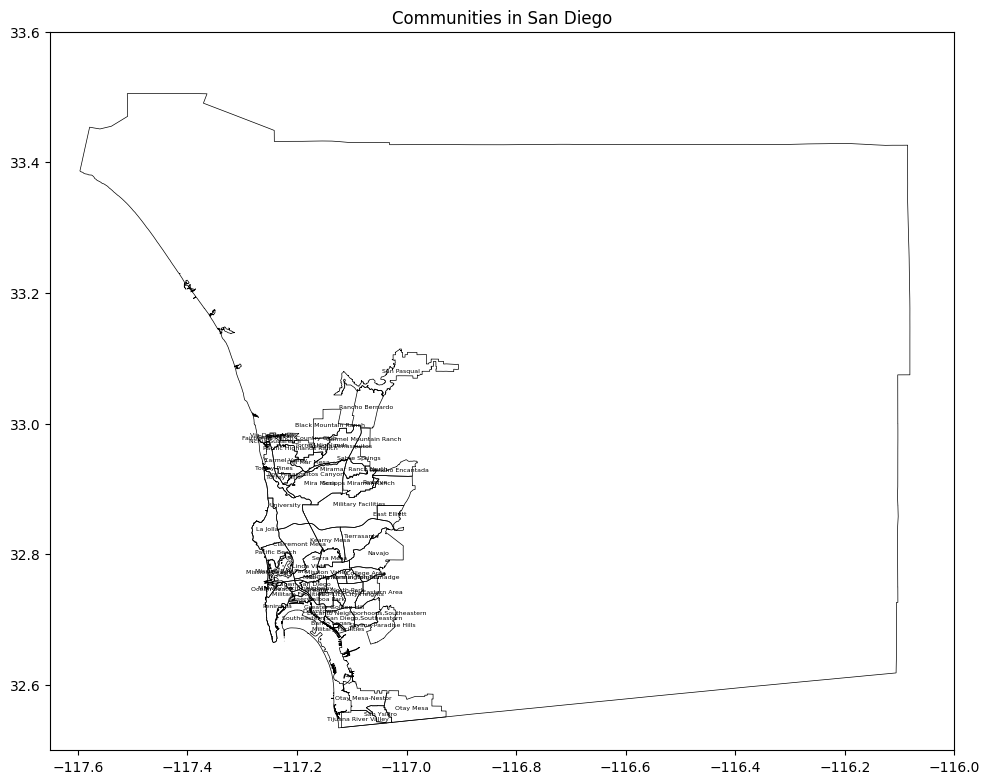

In [168]:
fig1, ax = plt.subplots(figsize=(10, 10))

bus_loc_plot = communities_gdf.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='black',
                     linewidth=0.5)#, norm=norm)

bus_loc_plot.set_xlim(-117.4,-116.9)
bus_loc_plot.set_ylim(32.5,33.3)


for x, y, label in zip(communities_gdf.geometry.centroid.x,
                      communities_gdf.geometry.centroid.y,
                      communities_gdf['community']):

        ax.text(x, y, label, fontsize=4.5, ha='center', va='center')


sd_county_gdf.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='black',
                     linewidth=0.5)#, norm=norm)

ax.set_title('Communities in San Diego')


bus_loc_plot.set_xlim(-117.65,-116.0)
bus_loc_plot.set_ylim(32.5,33.6)
plt.tight_layout()
plt.show()



In [169]:
print(communities_gdf['community'].values)

['Southeastern San Diego,Southeastern' 'Military Facilities'
 'Otay Mesa-Nestor' 'Otay Mesa' 'San Ysidro' 'Tijuana River Valley'
 'Mission Valley' 'Old Town San Diego' 'Midway-Pacific Highway'
 'Mid-City:City Heights' 'Encanto Neighborhoods,Southeastern'
 'Skyline-Paradise Hills' 'Rancho Bernardo' 'Mira Mesa' 'Uptown'
 'Tierrasanta' 'Torrey Hills' 'Serra Mesa' 'Military Facilities'
 'Barrio Logan' 'San Pasqual' 'Rancho Penasquitos'
 'Los Penasquitos Canyon' 'Carmel Valley' 'Kearny Mesa' 'Linda Vista'
 'Mid-City:Kensington-Talmadge' 'Mid-City:Normal Heights'
 'Greater North Park' 'Military Facilities' 'Balboa Park' 'Reserve'
 'Downtown' 'Torrey Pines' 'Torrey Highlands' 'Pacific Highlands Ranch'
 'Del Mar Mesa' 'Rancho Encantada' 'Scripps Miramar Ranch' 'University'
 'Reserve' 'Greater Golden Hill' 'Black Mountain Ranch'
 'Carmel Mountain Ranch' 'Via De La Valle' 'Fairbanks Ranch Country Club'
 'Reserve' 'Ncfua Subarea Ii' 'Reserve' 'Reserve' 'La Jolla'
 'East Elliott' 'Miramar Ranch No

In [170]:
intersect_both_list = list(set(community_df ['name'] .tolist()) & set( communities_gdf['community'].values.tolist()))
print(intersect_both_list)

['Tierrasanta', 'Rancho Bernardo', 'Serra Mesa', 'Balboa Park', 'Torrey Pines', 'Mission Beach', 'Carmel Valley', 'Otay Mesa', 'Mission Bay Park', 'Mira Mesa', 'Rancho Penasquitos', 'La Jolla', 'Linda Vista', 'Torrey Highlands', 'Kearny Mesa', 'Barrio Logan', 'Ocean Beach', 'Pacific Beach', 'Miramar Ranch North', 'San Ysidro', 'Sabre Springs', 'San Pasqual', 'Tijuana River Valley', 'Black Mountain Ranch']


In [171]:
sd_city = 'San Diego'
sd_boundaries_gdf = boundaries_gdf[boundaries_gdf['CITY'] == sd_city]
sd_city_boundaries_gdf = sd_boundaries_gdf.rename(columns={"CITY": "City"}).dissolve(by= 'City').reset_index()

/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/4011815397.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(shared_communities.geometry.centroid.x,
/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/4011815397.py:57: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  shared_communities.geometry.centroid.y,
/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/4011815397.py:77: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(shared_zip_gdf.geometry.centroid.x,
/var/folders/p3/dqqbfzkd0ln207r

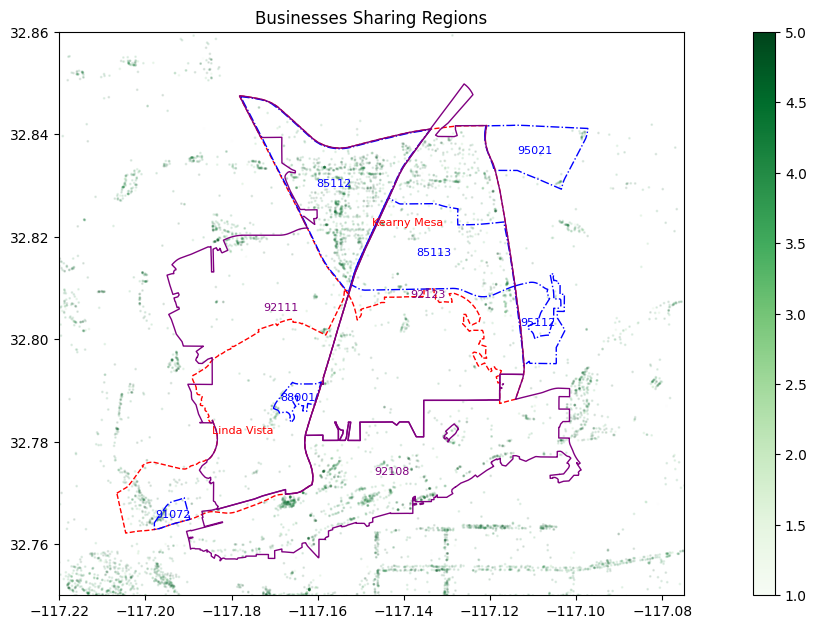

In [172]:
bg_list = [   85112, 85113,95112 ,  88001, 91072,95021]
shared_bg_gdf = block_group_gdf[block_group_gdf['ctblockgroup'].isin(bg_list)]
zip_list = [92111, 92123, 92108]
shared_zip_gdf = zipcode_gdf[zipcode_gdf['zipcode'].isin(zip_list)]


communities_list = ['Linda Vista', 'Kearny Mesa']
shared_communities = communities_gdf[communities_gdf['community'].isin(communities_list)]
fig1, ax = plt.subplots(figsize=(10, 10))

# create a colorbar axes whose height will match `ax`
divider = make_axes_locatable(ax)
# size controls width of colorbar (e.g. "3%"), pad controls gap
cax = divider.append_axes("right", size="3%", pad=0.1)



bus_shared_plot = business_location_gdf.plot(ax=ax,cax=cax,
                                          column='avg_rating',
                                          markersize=1, 
                                          legend =True, 
                                          alpha=0.1,
                                          cmap = 'Greens')# color='purple'


shared_communities.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='red',
                     linewidth=1,
                     linestyle='--'
                     )#, norm=norm)


shared_bg_gdf.plot(color = 'none',
                         ax=ax, 
                         edgecolor='blue',
                         linewidth=1,
                         linestyle='-.'
                         )

# sd_city_boundaries_gdf.plot(color = 'none',
#                          ax=ax, 
#                          edgecolor='black',
#                          linewidth=2.5)#, norm=norm)    


shared_zip_gdf.plot(color = 'none',
                                ax=ax,
                                edgecolor='purple',
                                linewidth=1)

bus_shared_plot.set_xlim(-117.22,-117.075)
bus_shared_plot.set_ylim(32.75,32.86)


for x, y, label in zip(shared_communities.geometry.centroid.x,
                      shared_communities.geometry.centroid.y,
                      shared_communities['community']):

        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='red')


# for x, y, label in zip(sd_city_boundaries_gdf.geometry.centroid.x,
#                       sd_city_boundaries_gdf.geometry.centroid.y,
#                       sd_city_boundaries_gdf['City']):

#         ax.text(x, y, label, fontsize=8, ha='center', va='center')

# block_group_sample_gdf = block_group_gdf.sample(frac=0.15, random_state=3)

# for x, y, label in zip(block_group_sample_gdf.geometry.centroid.x,
#                       block_group_sample_gdf.geometry.centroid.y,
#                       block_group_sample_gdf['ctblockgroup']):
#         ax.text(x, y, label, fontsize=8, ha='center', va='center')


for x, y, label in zip(shared_zip_gdf.geometry.centroid.x,
                      shared_zip_gdf.geometry.centroid.y,
                      shared_zip_gdf['zipcode']):
        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='purple')





for x, y, label in zip(shared_bg_gdf.geometry.centroid.x,
                      shared_bg_gdf.geometry.centroid.y,
                      shared_bg_gdf['ctblockgroup']):

        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='blue')
ax.set_title('Businesses Sharing Regions')


plt.show()


/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/615369975.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(communities_gdf.geometry.centroid.x,
/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/615369975.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  communities_gdf.geometry.centroid.y,


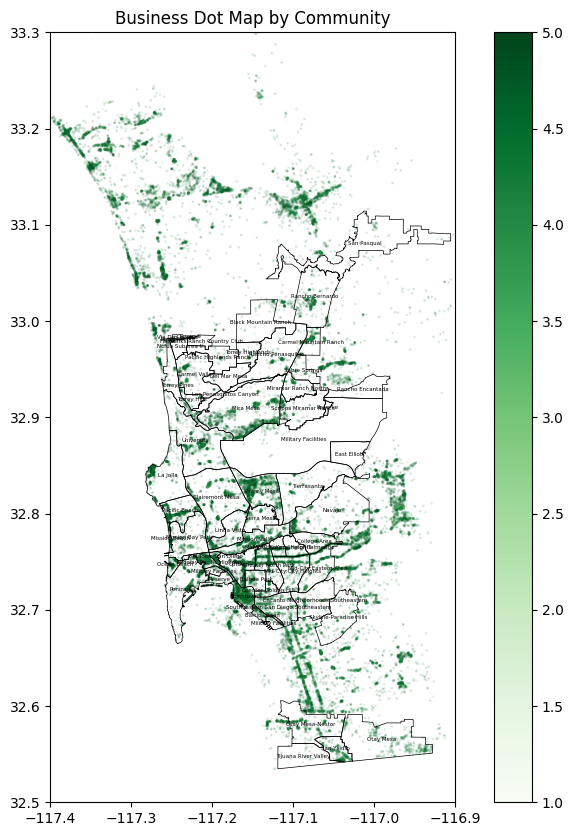

In [173]:
fig1, ax = plt.subplots(figsize=(10, 10))

bus_loc_plot = business_location_gdf.plot(ax=ax,
                                          column='avg_rating',
                                          markersize=1, 
                                          legend =True, 
                                          alpha=0.1,
                                          cmap = 'Greens')# color='purple'


communities_gdf.plot(color = 'none', 
                     ax=ax, 
                     edgecolor='black',
                     linewidth=0.5)#, norm=norm)

bus_loc_plot.set_xlim(-117.4,-116.9)
bus_loc_plot.set_ylim(32.5,33.3)


for x, y, label in zip(communities_gdf.geometry.centroid.x,
                      communities_gdf.geometry.centroid.y,
                      communities_gdf['community']):

        ax.text(x, y, label, fontsize=4, ha='center', va='center')

ax.set_title('Business Dot Map by Community')

plt.show()



/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/1723707820.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/1723707820.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sd_cities_boundaries_gdf.geometry.centroid.y,


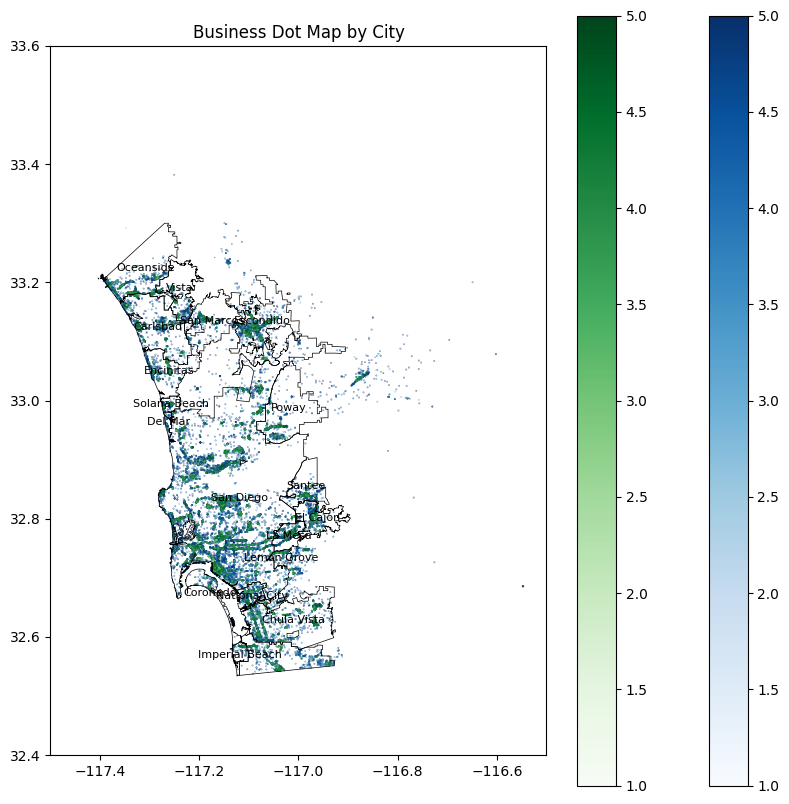

In [174]:
fig2, ax2 = plt.subplots(figsize=(10, 10))
# bus_loc_cities_plot = business_location_gdf.plot(ax=ax2, color='purple',markersize=1, alpha=0.1)

bus_loc_cities_plot = business_location_gdf[business_location_gdf['is_franchise']==0].plot(ax=ax2,
                                          column='avg_rating',
                                          markersize=0.05, 
                                          legend =True, 
                                          alpha=1,
                                          cmap = 'Blues')# color='purple'

business_location_gdf[business_location_gdf['is_franchise']==1].plot(ax=ax2,
                                          column='avg_rating',
                                          markersize=0.05, 
                                          legend =True, 
                                          alpha=1,
                                          cmap = 'Greens')# color='purple'


sd_cities_boundaries_gdf.plot(color = 'none', ax=ax2, edgecolor='black', linewidth=0.5)#, norm=norm)

bus_loc_cities_plot.set_xlim(-117.5,-116.5)
bus_loc_cities_plot.set_ylim(32.4,33.6)


for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
                      sd_cities_boundaries_gdf.geometry.centroid.y,
                      sd_cities_boundaries_gdf['City']):

        ax2.text(x, y, label, fontsize=8, ha='center', va='center')

ax2.set_title('Business Dot Map by City')

plt.show()



In [175]:
block_group_gdf.dropna(axis=1).describe()

,id,ctblockgroup,countyfp,tractce,blkgrpce,ogc_fid,statefp,average_income,median_income,income_under_15000,...,female_population_0_9,female_population_10_19,female_population_20_29,female_population_30_39,female_population_40_49,female_population_50_59,female_population_60_69,female_population_70_79,female_population_80_plus,female_population_total
count,2057.000000,2057.000000,2057.0,2057.000000,2057.000000,2057.000000,2057.0,2057.000000,2057.000000,2057.000000,...,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000,2057.000000
mean,1029.000000,126186.350510,73.0,12618.428780,2.062713,1094.310160,6.0,94259.644628,80704.745746,45.824502,...,92.184249,96.618376,117.007778,119.612543,97.003889,94.125912,91.137093,60.634419,35.838600,804.162859
std,593.949072,60409.251607,0.0,6040.929812,1.026144,630.206001,0.0,32371.134797,30040.998200,51.207271,...,91.044680,99.271896,147.072089,73.763128,55.781736,50.107882,49.774703,41.644544,37.472691,450.650745
min,1.000000,1001.000000,73.0,100.000000,1.000000,5.000000,6.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
25%,515.000000,83482.000000,73.0,8348.000000,1.000000,573.000000,6.0,69880.000000,56242.000000,14.000000,...,46.000000,52.000000,62.000000,75.000000,62.000000,60.000000,57.000000,32.000000,14.000000,545.000000
50%,1029.000000,134012.000000,73.0,13401.000000,2.000000,1087.000000,6.0,91219.000000,78844.000000,30.000000,...,79.000000,84.000000,97.000000,109.000000,87.000000,85.000000,82.000000,51.000000,26.000000,736.000000
75%,1543.000000,178102.000000,73.0,17810.000000,3.000000,1658.000000,6.0,114464.000000,102481.000000,60.000000,...,121.000000,123.000000,147.000000,152.000000,121.000000,120.000000,118.000000,80.000000,45.000000,991.000000
max,2057.000000,221024.000000,73.0,22102.000000,7.000000,2172.000000,6.0,232678.000000,181991.000000,544.000000,...,3099.000000,2945.000000,5228.000000,1696.000000,782.000000,547.000000,403.000000,376.000000,395.000000,12129.000000


In [176]:
block_group_gdf

,id,geo_id,ctblockgroup,countyfp,tractce,blkgrpce,ogc_fid,statefp,average_income,median_income,...,cs_school_food,cs_alcohol,cs_coffee_tea,cs_retail_goods,cs_housing,cs_pet_food,geom,geom_wkt,centroid_wkt,geometry
0,1,6.073001e+10,10001,73,1000,1,497,6,84570,65007,...,140611.0,78255.0,236626.0,18069548.0,39402526.0,193892.0,0106000020E61000000100000001030000000100000081...,MULTIPOLYGON(((-117.139552001244 32.7672929995...,POINT(-117.141339781151 32.763522520968),"MULTIPOLYGON (((-117.13955 32.76729, -117.1396..."
1,2,6.073010e+10,100011,73,10001,1,932,6,88556,74198,...,77156.0,38808.0,111285.0,9388369.0,19533948.0,99243.0,0106000020E6100000010000000103000000010000005E...,MULTIPOLYGON(((-117.050494000916 32.5838399992...,POINT(-117.055176616996 32.5852793767876),"MULTIPOLYGON (((-117.05049 32.58384, -117.0505..."
2,3,6.073010e+10,100012,73,10001,2,939,6,89693,78309,...,170069.0,85541.0,245297.0,20694236.0,43057542.0,218756.0,0106000020E610000001000000010300000001000000FA...,MULTIPOLYGON(((-117.058324000663 32.5904809989...,POINT(-117.055481329309 32.5870370857044),"MULTIPOLYGON (((-117.05832 32.59048, -117.0583..."
3,4,6.073001e+10,10002,73,1000,2,498,6,84853,69008,...,131594.0,69631.0,208272.0,16455832.0,33336356.0,181192.0,0106000020E61000000100000001030000000100000049...,MULTIPOLYGON(((-117.143778000325 32.7609579991...,POINT(-117.141940565517 32.7600381925693),"MULTIPOLYGON (((-117.14378 32.76096, -117.1440..."
4,5,6.073001e+10,10003,73,1000,3,499,6,85964,67273,...,146427.0,81492.0,246413.0,18816988.0,41032398.0,201912.0,0106000020E61000000100000001030000000100000046...,MULTIPOLYGON(((-117.14501800108 32.75909699882...,POINT(-117.141939137067 32.7581694568747),"MULTIPOLYGON (((-117.14502 32.7591, -117.14527..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2052,2053,6.073010e+10,98052,73,9805,2,929,6,104834,89626,...,80496.0,36089.0,112482.0,9089527.0,16150972.0,97716.0,0106000020E610000001000000010300000001000000A3...,MULTIPOLYGON(((-117.034503001602 32.8314619986...,POINT(-117.032738348537 32.8175004624173),"MULTIPOLYGON (((-117.0345 32.83146, -117.03456..."
2053,2054,6.073010e+10,98053,73,9805,3,930,6,148670,124085,...,195315.0,95655.0,295835.0,23892166.0,42530731.0,258164.0,0106000020E61000000100000001030000000100000088...,MULTIPOLYGON(((-117.05170200104 32.81259999944...,POINT(-117.04543152979 32.8081786034056),"MULTIPOLYGON (((-117.0517 32.8126, -117.05184 ..."
2054,2055,6.073010e+10,98054,73,9805,4,931,6,111112,89681,...,206812.0,95996.0,300774.0,24775757.0,43005389.0,284210.0,0106000020E6100000010000000103000000010000008D...,MULTIPOLYGON(((-117.046669000545 32.8175029990...,POINT(-117.050500911858 32.8148906754566),"MULTIPOLYGON (((-117.04667 32.8175, -117.04672..."
2055,2056,6.073010e+10,99011,73,9901,1,150,6,67690,58248,...,3439.0,1471.0,4105.0,354521.0,723883.0,3667.0,0106000020E61000000100000001030000000100000046...,MULTIPOLYGON(((-117.243726000706 32.7078149995...,POINT(-117.244585851251 32.6901307888089),"MULTIPOLYGON (((-117.24373 32.70781, -117.2444..."


/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/2905411964.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(block_group_sample_gdf.geometry.centroid.x,
/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/2905411964.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  block_group_sample_gdf.geometry.centroid.y,
/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/2905411964.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
/var/folders/

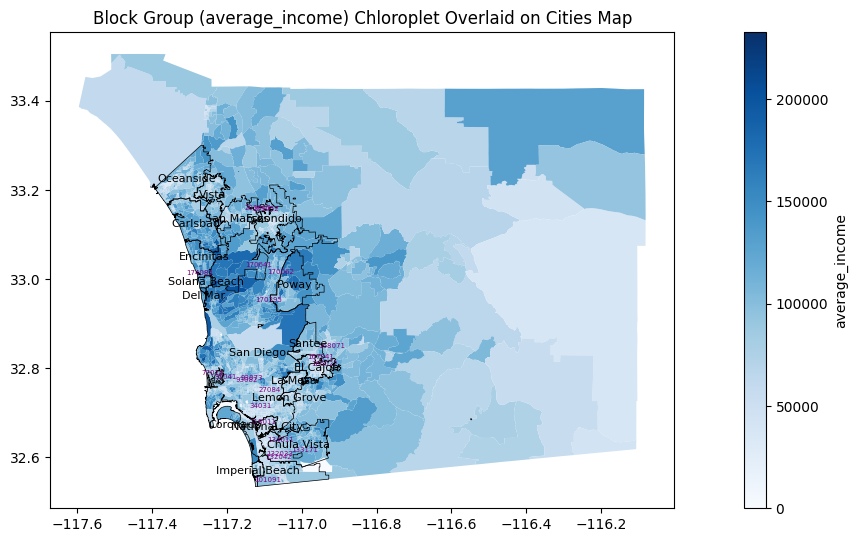

In [177]:


fig3, ax3 = plt.subplots(figsize=(10, 10))
# create a colorbar axes whose height will match `ax`
divider = make_axes_locatable(ax3)
# size controls width of colorbar (e.g. "3%"), pad controls gap
cax3 = divider.append_axes("right", size="3%", pad=0.1)


bg_plot_var = 'average_income'
blockgroup_cities_plot = block_group_gdf.plot(ax=ax3, cax = cax3,

                                          column=bg_plot_var,
                                          markersize=0.05, 
                                          legend =True, legend_kwds={'label': bg_plot_var},
                                          alpha=1,
                                          cmap = 'Blues')# color='purple'



sd_cities_boundaries_gdf.plot(color = 'none', ax=ax3, edgecolor='black', linewidth=0.5)#, norm=norm)

#use a sample to add the block group names since there are so many
block_group_sample_gdf = block_group_gdf.sample(frac=0.01, random_state=42)
for x, y, label in zip(block_group_sample_gdf.geometry.centroid.x,
                      block_group_sample_gdf.geometry.centroid.y,
                      block_group_sample_gdf['ctblockgroup']):

        ax3.text(x, y, label, fontsize=5, ha='center', va='center', color='purple')


for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
                      sd_cities_boundaries_gdf.geometry.centroid.y,
                      sd_cities_boundaries_gdf['City']):

        ax3.text(x, y, label, fontsize=8, ha='center', va='center')

ax3.set_title(f'Block Group ({bg_plot_var}) Chloroplet Overlaid on Cities Map')

plt.show()


/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/2448663783.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
/var/folders/p3/dqqbfzkd0ln207r8z90_jbnc0000gp/T/ipykernel_3906/2448663783.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sd_cities_boundaries_gdf.geometry.centroid.y,


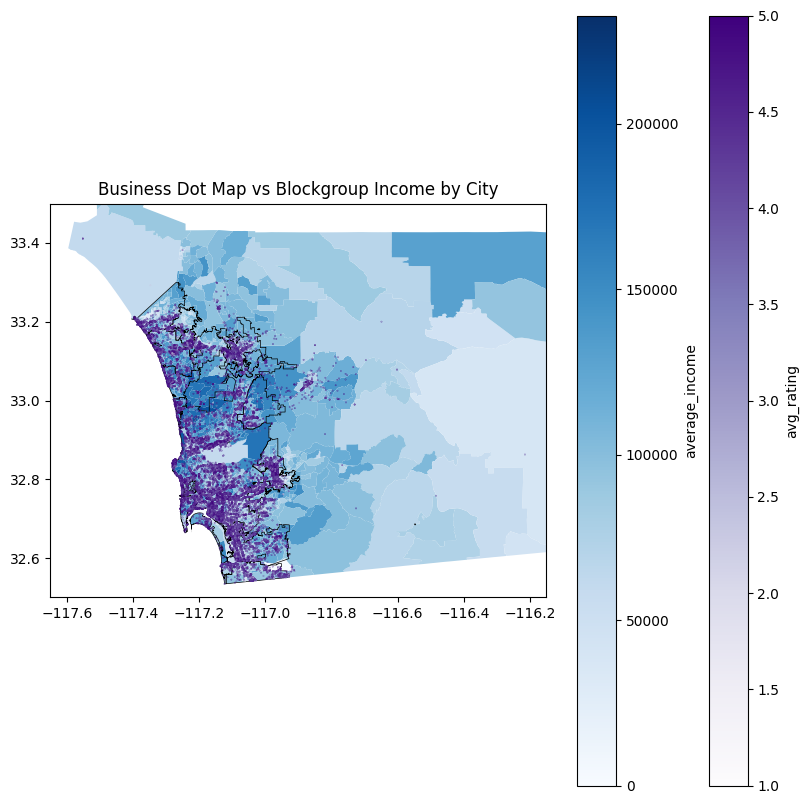

In [180]:
fig4, ax4 = plt.subplots(figsize=(10, 10))
# bus_loc_cities_plot = business_location_gdf.plot(ax=ax2, color='purple',markersize=1, alpha=0.1)

bus_plot_var = 'avg_rating'
bus_bg_cities_plot = business_location_gdf.sample(frac=1,random_state=42).plot(ax=ax4,
                                          column=bus_plot_var,
                                          markersize=0.05, 
                                          legend =True, legend_kwds={'label': bus_plot_var},
                                          alpha=1,
                                          cmap = 'Purples',zorder= 10)# color='purple'



bg_plot_var = 'average_income'# 'n37_sales'
blockgroup_cities_plot = block_group_gdf.plot(ax=ax4,
                                          column=bg_plot_var,
                                          markersize=0.05, 
                                          legend =True, legend_kwds={'label': bg_plot_var},
                                          alpha=1,
                                          cmap = 'Blues')# color='purple'

sd_cities_boundaries_gdf.plot(color = 'none', ax=ax4, edgecolor='black', linewidth=0.5)#, norm=norm)

bus_bg_cities_plot.set_xlim(-117.65,-116.15)
bus_bg_cities_plot.set_ylim(32.5,33.5)


for x, y, label in zip(sd_cities_boundaries_gdf.geometry.centroid.x,
                      sd_cities_boundaries_gdf.geometry.centroid.y,
                      sd_cities_boundaries_gdf['City']):

        ax2.text(x, y, label, fontsize=8, ha='center', va='center')

ax4.set_title('Business Dot Map vs Blockgroup Income by City')

plt.show()



Ignore below for now. WIP. Adding elevation

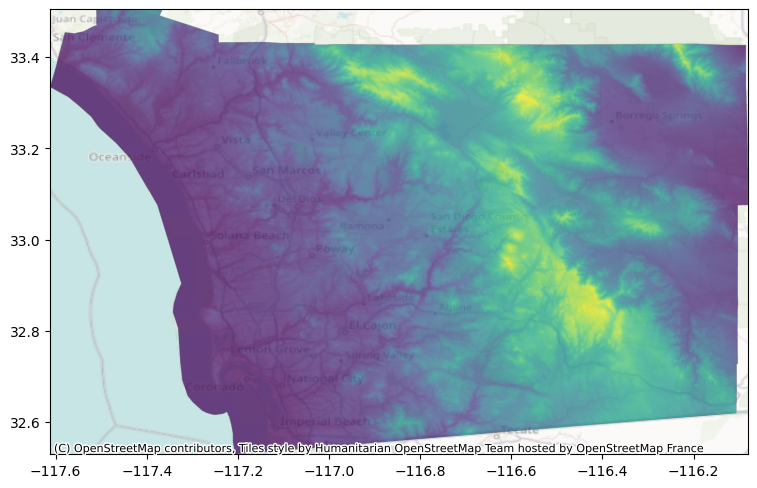

In [179]:
elevation_filename = "../data/external/nasadem_sd.tif"
elevation_path = os.path.join(data_path, elevation_filename)


f, ax = plt.subplots(1, figsize=(9, 9))
r = rasterio.open(elevation_path)
rioshow(r, zorder=1, alpha=0.75, ax=ax)
cx.add_basemap(ax, alpha=0.5, crs=r.crs)